<a href="https://colab.research.google.com/github/ahana2611/Self-study-Projects/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **XGBoost model for MDR dataset**

Install & imports

In [5]:
#install xgboost library inside notebook environment and in 'quiet mode' - to reduce installation logs
!pip install xgboost -q

#core libraries installation
import pandas as pd #data manipulation, read csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns #easier and prettier plots

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report #formatted summary of precision/recall/F1/support.
)

from xgboost import XGBClassifier

In [8]:
#sets default plotting style
sns.set(style="whitegrid", context="talk")


In [9]:
from google.colab import files
uploaded = files.upload()

Saving medical_dataset_type1_extended.csv to medical_dataset_type1_extended.csv


In [10]:
medical = pd.read_csv("medical_dataset_type1_extended.csv")

In [11]:
print("First few rows:")
print(medical.head())


First few rows:
   age  fever_duration  cough  weight_loss  night_sweats  mdr_contact  \
0   45               7      1            0             0            0   
1   38               9      1            0             0            0   
2   47               7      0            0             0            0   
3   58               9      1            0             0            0   
4   37               2      1            0             1            0   

   tb_history    sputum_result   BMI  chest_pain  HIV_status  diabetes_status  \
0           0  Medium positive  26.2           0           0                0   
1           0         Negative  20.4           0           0                0   
2           1     Low positive  27.4           1           0                0   
3           0         Negative  22.0           0           0                0   
4           0     Low positive  29.8           0           0                1   

   fatigue  MDR_label  
0        0          0  
1        0

In [12]:
print("\nInfo:")
print(medical.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2000 non-null   int64  
 1   fever_duration   2000 non-null   int64  
 2   cough            2000 non-null   int64  
 3   weight_loss      2000 non-null   int64  
 4   night_sweats     2000 non-null   int64  
 5   mdr_contact      2000 non-null   int64  
 6   tb_history       2000 non-null   int64  
 7   sputum_result    2000 non-null   object 
 8   BMI              2000 non-null   float64
 9   chest_pain       2000 non-null   int64  
 10  HIV_status       2000 non-null   int64  
 11  diabetes_status  2000 non-null   int64  
 12  fatigue          2000 non-null   int64  
 13  MDR_label        2000 non-null   int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 218.9+ KB
None


In [13]:
print("\nTarget distribution:")
print(medical["MDR_label"].value_counts(normalize=True))



Target distribution:
MDR_label
0    0.946
1    0.054
Name: proportion, dtype: float64


# **Basic EDA & visualisation**

In [15]:
# Numerical features (continuous)
numeric_features = ["age", "fever_duration", "BMI"]

In [27]:
binary_features = [
    "cough",
    "night_sweats",      # if your column is 'night_sweats', change here
    "mdr_contact",
    "tb_history",
    "chest_pain",
    "HIV_status",
    "diabetes_status",
    "fatigue"
]

In [17]:
categorical_feature = ["sputum_result"]

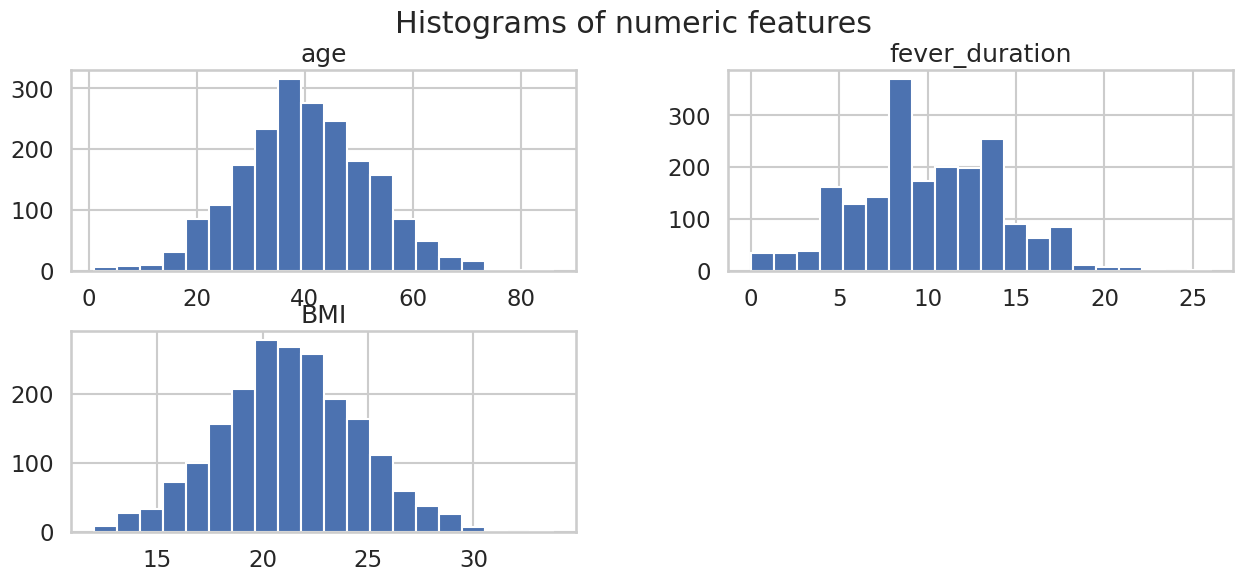

In [22]:
medical[numeric_features].hist(bins=20, figsize=(15, 6))
plt.suptitle("Histograms of numeric features")
plt.show()

<Figure size 800x600 with 0 Axes>

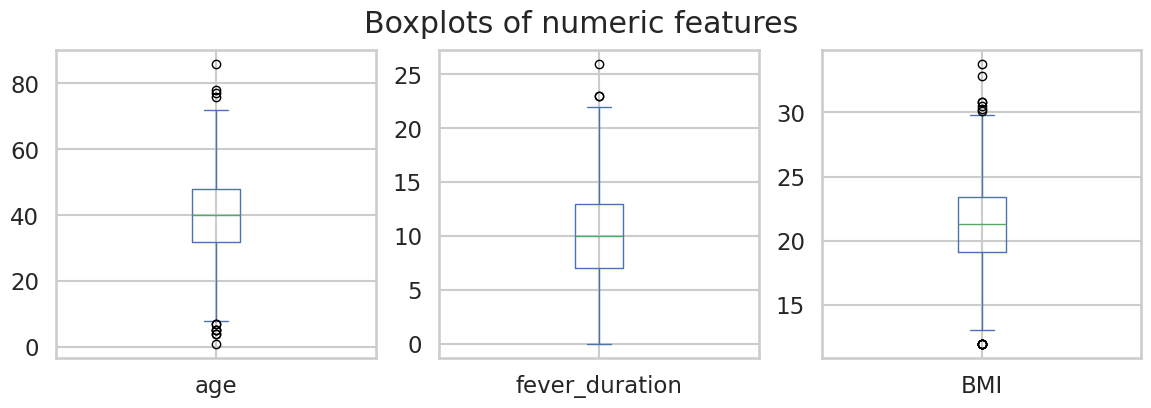

In [23]:
#Box plots for numeric features (overall)
plt.figure(figsize=(8, 6))
medical[numeric_features].plot(kind="box", subplots=True, layout=(1, 3), figsize=(14, 4))
plt.suptitle("Boxplots of numeric features")
plt.show()

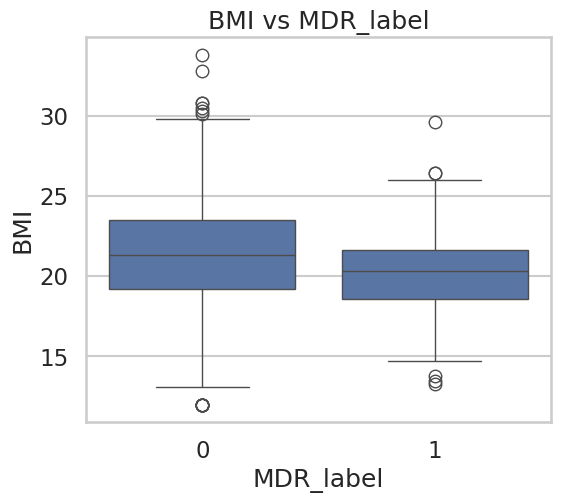

In [29]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="MDR_label", y="BMI", data=medical)
plt.title("BMI vs MDR_label")
plt.show()

In [28]:
corr_cols = numeric_features + binary_features
corr = medical[corr_cols].corr()

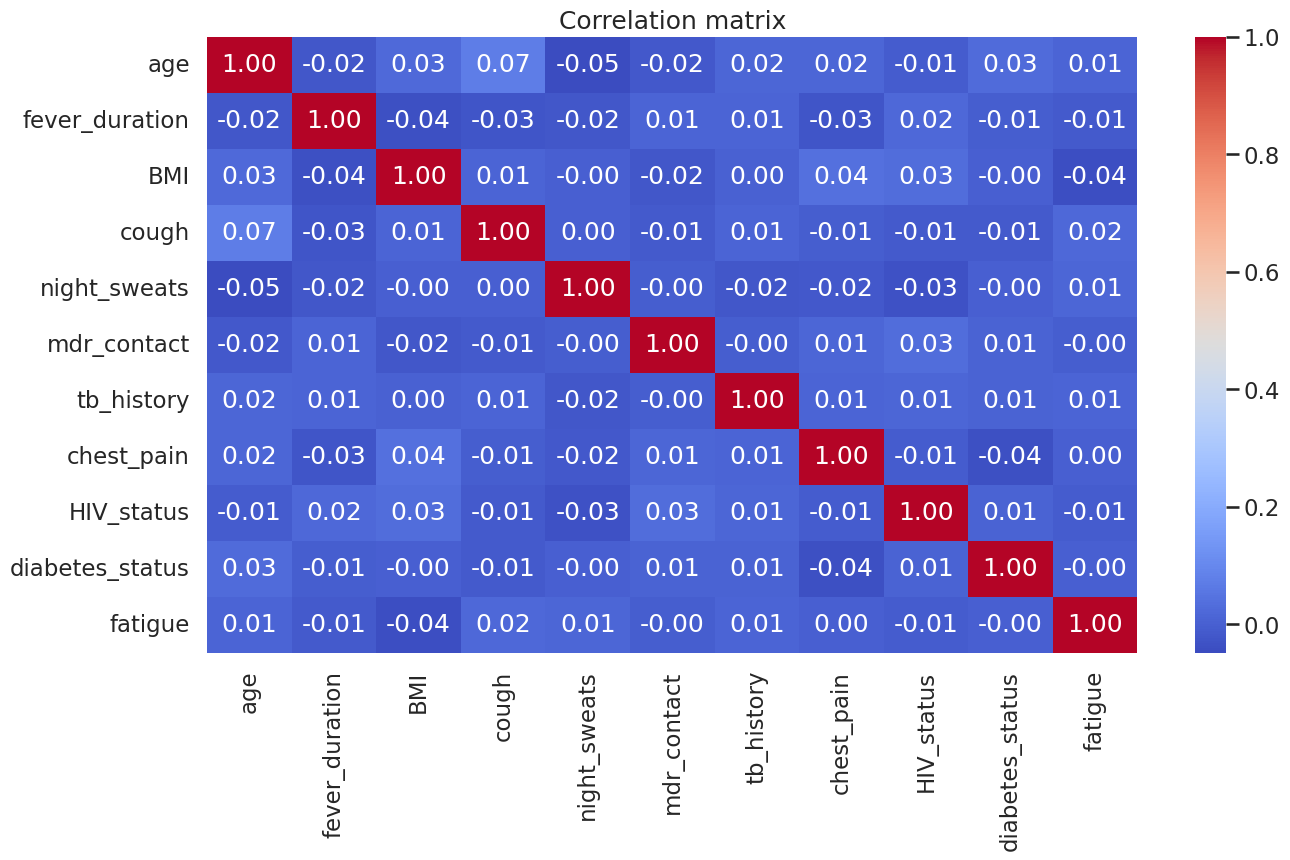

In [31]:
plt.figure(figsize=(15, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

# **Preprocessing**

In [33]:
#make sure binary columns are numeric 0/1 (if they are 'yes'/'no', uncomment):
# for col in bin_features + ["MDR_label"]:
#     df[col] = df[col].map({"no": 0, "yes": 1})

In [34]:
print("\nUnique sputum_result values:", medical["sputum_result"].unique())


Unique sputum_result values: ['Medium positive' 'Negative' 'Low positive' 'High positive']


In [53]:
sputum_order = [["Negative", "Low positive", "Medium positive", "High positive"]]


In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("bin", "passthrough", binary_features),  # already numeric 0/1
        ("cat", OrdinalEncoder(categories=sputum_order), categorical_feature)
    ]
)

# **Train-test split**

In [55]:
X = medical[numeric_features + binary_features + categorical_feature]
y = medical["MDR_label"]


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [57]:
print("\nTrain size:", X_train.shape, " Test size:", X_test.shape)



Train size: (1600, 12)  Test size: (400, 12)


# **Build XGBoost pipeline**

In [58]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [59]:
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# **Train + basic performance (train vs test)**

In [60]:
clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fever_duration',
                                                   'BMI']),
                                                 ('bin', 'passthrough',
                                                  ['cough', 'night_sweats',
                                                   'mdr_contact', 'tb_history',
                                                   'chest_pain', 'HIV_status',
                                                   'diabetes_status',
                                                   'fatigue']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Negative',
                                                                              'Low '
                                                                              'positive',
                                                                              'Medium '
                                                                              'positive',
                                                                              'High '
                                                                              'positive']]),
                                                  [...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [61]:
# Predictions
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)
y_test_proba = clf.predict_proba(X_test)[:, 1]

In [62]:
# Metrics
def print_metrics(split, y_true, y_pred, y_proba=None):
    print(f"\n=== {split} metrics ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    if y_proba is not None:
        print("ROC-AUC  :", roc_auc_score(y_true, y_proba))

In [63]:
print_metrics("Train", y_train, y_train_pred, clf.predict_proba(X_train)[:, 1])



=== Train metrics ===
Accuracy : 0.995
Precision: 1.0
Recall   : 0.9069767441860465
F1-score : 0.9512195121951219
ROC-AUC  : 0.9999462382108076


In [64]:
print_metrics("Test", y_test, y_test_pred, y_test_proba)



=== Test metrics ===
Accuracy : 0.9725
Precision: 0.9230769230769231
Recall   : 0.5454545454545454
F1-score : 0.6857142857142857
ROC-AUC  : 0.9856902356902357


In [65]:
print("\nClassification report (Test):")
print(classification_report(y_test, y_test_pred))



Classification report (Test):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       378
           1       0.92      0.55      0.69        22

    accuracy                           0.97       400
   macro avg       0.95      0.77      0.84       400
weighted avg       0.97      0.97      0.97       400



# **Confusion Matrix**

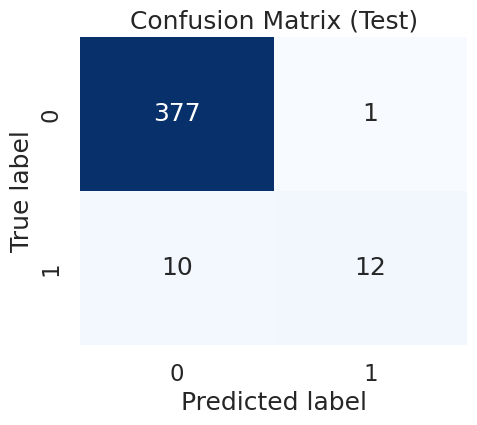

In [66]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix (Test)")
plt.show()

# **Cross-validation & learning curve (overfitting check)**

In [67]:
# Cross-validation scores
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print("\nCross-validation ROC-AUC scores:", cv_scores)
print("Mean CV ROC-AUC:", cv_scores.mean())



Cross-validation ROC-AUC scores: [0.98404322 0.99597939 0.97895623 0.97967773 0.99603175]
Mean CV ROC-AUC: 0.9869376641144451


In [68]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    clf, X, y,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

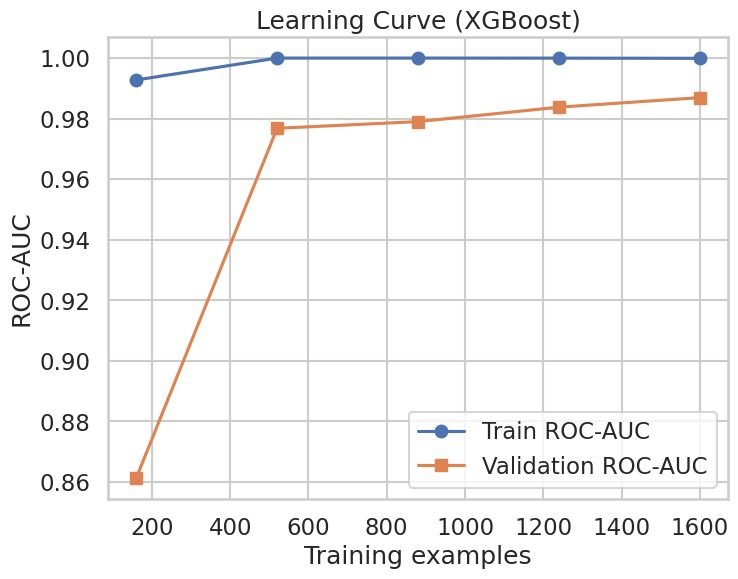

In [69]:
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, marker="o", label="Train ROC-AUC")
plt.plot(train_sizes, val_scores_mean, marker="s", label="Validation ROC-AUC")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

**Observation**: model is overfitting when trained with very little data, because it can easily memorize patterns then.

Our model benefits a lot from having additional data

# **Feature importance**

In [70]:
clf.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'fever_duration',
                                                   'BMI']),
                                                 ('bin', 'passthrough',
                                                  ['cough', 'night_sweats',
                                                   'mdr_contact', 'tb_history',
                                                   'chest_pain', 'HIV_status',
                                                   'diabetes_status',
                                                   'fatigue']),
                                                 ('cat',
                                                  OrdinalEncoder(categories=[['Negative',
                                                                              'Low '
                                                                              'positive',
                                                                              'Medium '
                                                                              'positive',
                                                                              'High '
                                                                              'positive']]),
                                                  [...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [71]:
numeric_names = numeric_features
binary_names = binary_features
categorical_names = categorical_feature

In [73]:
all_feature_names = numeric_names + binary_names + categorical_names

In [74]:
xgb_fitted = clf.named_steps["model"]
importances = xgb_fitted.feature_importances_


In [75]:
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)


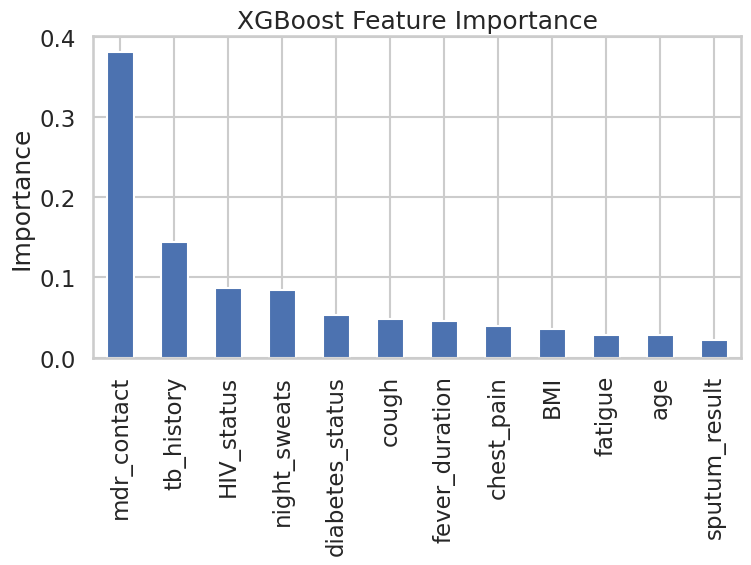

In [76]:
plt.figure(figsize=(8, 6))
feat_imp.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()